# Load ZTF light curve

In [5]:
ra  = 234.8839713056
dec = 50.4607560776

ra =284.6898542 
dec =-7.8740056

from ztf_lightcurves.ztf_lc import get_lightcurve
qry = get_lightcurve(ra, dec)

## Inspect structure of output

In [6]:
print(qry.keys())
print(type(qry["source"]), list(qry["source"].keys()))
print(type(qry["lc"]), qry["lc"].shape,qry["lc"].columns.tolist())
qry["lc"].head()

dict_keys(['source', 'lc'])
<class 'dict'> ['gaia_id', 'ra', 'decl', 'mag_ref', 'mag_err_ref', 'objtype', 'field', 'ccd', 'quad', 'filt', 'sep_arcsec']
<class 'pandas.core.frame.DataFrame'> (12, 22) ['jd', 'bjd', 'filterid', 'exptime', 'pid', 'field', 'ccd', 'quad', 'imstat', 'infobits', 'seeing', 'mzpsci', 'mzpsciunc', 'mzpscirms', 'clrco', 'clrcounc', 'maglim', 'airmass', 'nps1matches', 'flux', 'flux_err', 'flag']


,jd,bjd,filterid,exptime,pid,field,ccd,quad,imstat,infobits,...,mzpsciunc,mzpscirms,clrco,clrcounc,maglim,airmass,nps1matches,flux,flux_err,flag
0,2.459853e+06,2.459853e+06,1,30.0,2,1430,7,3,1,0,...,0.000036,0.040365,-0.077162,0.000065,20.490000,1.329,892,19.583313,33.501705,0
1,2.459853e+06,2.459853e+06,1,30.0,3,1430,7,3,1,0,...,0.000017,0.028259,-0.076075,0.000031,20.540001,1.332,896,-3.733829,30.866512,0
2,2.459859e+06,2.459859e+06,1,30.0,2,1430,7,3,1,0,...,0.000026,0.034584,-0.029424,0.000047,19.320000,2.293,904,85.257965,103.486862,0
3,2.459859e+06,2.459859e+06,1,30.0,3,1430,7,3,1,0,...,0.000032,0.038950,-0.049820,0.000058,19.280001,2.303,904,-110.192245,106.489067,0
4,2.459815e+06,2.459815e+06,2,30.0,3,1430,7,3,1,0,...,0.000019,0.029425,0.088661,0.000034,20.219999,1.439,904,97.673386,30.052452,0


## Inspect lightcurve

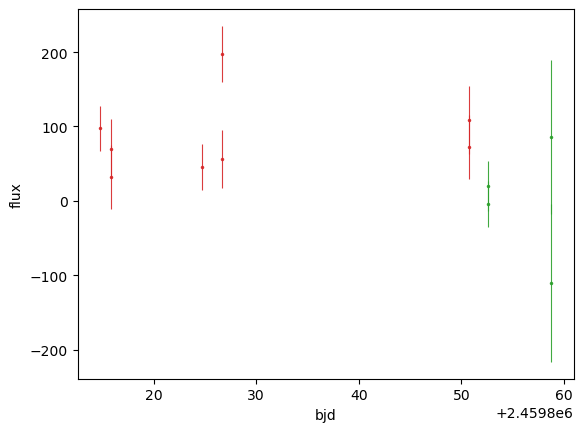

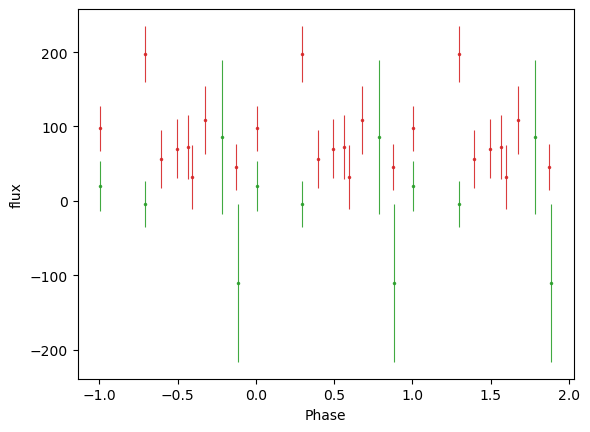

In [7]:
from ztf_lightcurves.plotting import plot_raw_lightcurve, plot_phase_folded_binned_lightcurve
plot_raw_lightcurve(qry)
period = 414.7915404 / 86400
ax = plot_phase_folded_binned_lightcurve(qry, period=period, num_bins=100)

## Optional: Inspect structure of field h5 file

In [4]:
import h5py
from ztf_lightcurves.ztf import get_field_ids
from ztf_lightcurves.ztf_lc import get_h5_filename

# Identify the ZTF field containing target coordinates
results = get_field_ids(ra, dec)
field, ccd, quad = results[0]

fname = get_h5_filename(field, ccd, quad, 'i')
with h5py.File(fname, "r") as f:
    def visit(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"{name}  DATASET  shape={obj.shape}  dtype={obj.dtype}\n")
        else:
            print(f"{name}  GROUP\n")
            
    f.visititems(visit)        

data  GROUP

data/exposures  DATASET  shape=(88,)  dtype={'names': ['jd', 'bjd', 'filterid', 'exptime', 'pid', 'field', 'ccd', 'quad', 'imstat', 'infobits', 'seeing', 'mzpsci', 'mzpsciunc', 'mzpscirms', 'clrco', 'clrcounc', 'maglim', 'airmass', 'nps1matches'], 'formats': ['<f8', '<f8', '<u2', '<f4', '<u2', '<u2', '<u2', '<u2', '<u2', '<u8', '<f4', '<f8', '<f8', '<f8', '<f8', '<f8', '<f4', '<f4', '<u8'], 'offsets': [0, 8, 16, 20, 24, 26, 28, 30, 32, 40, 48, 56, 64, 72, 80, 88, 96, 100, 104], 'itemsize': 112}

data/sourcedata  DATASET  shape=(1031008,)  dtype={'names': ['flux', 'flux_err', 'flag'], 'formats': ['<f4', '<f4', '<u2'], 'offsets': [0, 4, 8], 'itemsize': 12}

data/sources  DATASET  shape=(11716,)  dtype={'names': ['gaia_id', 'ra', 'decl', 'mag_ref', 'mag_err_ref', 'objtype'], 'formats': ['<u8', '<f4', '<f4', '<f4', '<f4', '<u2'], 'offsets': [0, 8, 12, 16, 20, 24], 'itemsize': 32}

